In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 16.1 MB/s eta 0:00:00

Import Library

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models, Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.manifold import TSNE


Config

In [ ]:
API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS = 2048
MAX_PER_CLASS = 50000

SEED = 42
EPOCHS_FINAL = 30
BATCH_SIZE = 32
VAL_SPLIT = 0.2

# Set seed for reproducibility
def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")

Seed set to 42
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']


Load Data from Materials Project

In [ ]:
def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        # Search for perovskite materials
        robo_docs = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs][:50000]

        print(f"Found {len(perov_mpids)} perovskite materials")

        # Get material summaries
        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                   "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            # Collect data
            record = {
                'material_id': str(doc.material_id),
                'formula': str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density': float(doc.density) if hasattr(doc, 'density') else None,
                'volume': float(doc.volume) if hasattr(doc, 'volume') else None,
                'nsites': int(doc.nsites) if hasattr(doc, 'nsites') else None,
                'structure': structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")

    return pd.DataFrame(data_records)

# Load data
print("Loading data from Materials Project...")
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")

Loading data from Materials Project...


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


Exploratory Data Analysis - Data Types & Sample Data

In [ ]:
# Check data types
print("="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)
print()

# Display columns/features
print("="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")
print()

# Display top 4 samples (excluding structure column for readability)
print("="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())

DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id formula crystal_system   density     volume  nsites
0  mp-1183288  BaInO3          cubic  6.331162  78.721649       5
1  mp-1183286  BaDyO3          cubic  6.651911  86.828787       5
2  mp-1183284  BaLiO3          cubic  4.677365  68.257565       5
3  mp-1183282  BaBeO3          cubic  5.464992  59.049462       5


Check Missing Values

In [ ]:
# Check missing values
print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_data = df_materials.isnull().sum()
missing_percent = (df_materials.isnull().sum() / len(df_materials)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percent.values
})

print(missing_df.to_string(index=False))

# Visualize missing values only if there are any
if missing_percent.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_percent[missing_percent > 0].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontweight='bold', fontsize=14)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\n⚠ Total missing values: {missing_data.sum()}")
else:
    print("\n" + "="*70)
    print("✓ NO MISSING VALUES FOUND!")
    print("="*70)
    print("All columns are complete. Data quality is excellent!")


MISSING VALUES ANALYSIS
        Column  Missing Count  Missing Percentage
   material_id              0                 0.0
       formula              0                 0.0
crystal_system              0                 0.0
       density              0                 0.0
        volume              0                 0.0
        nsites              0                 0.0
     structure              0                 0.0

✓ NO MISSING VALUES FOUND!
All columns are complete. Data quality is excellent!


Crystal System Distribution (Before XRD)


CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)

Count by Crystal System:
crystal_system
cubic           4877
orthorhombic    1003
monoclinic       869
tetragonal       266
Name: count, dtype: int64

Percentage by Crystal System:
  Cubic          :  69.52%
  Orthorhombic   :  14.30%
  Monoclinic     :  12.39%
  Tetragonal     :   3.79%


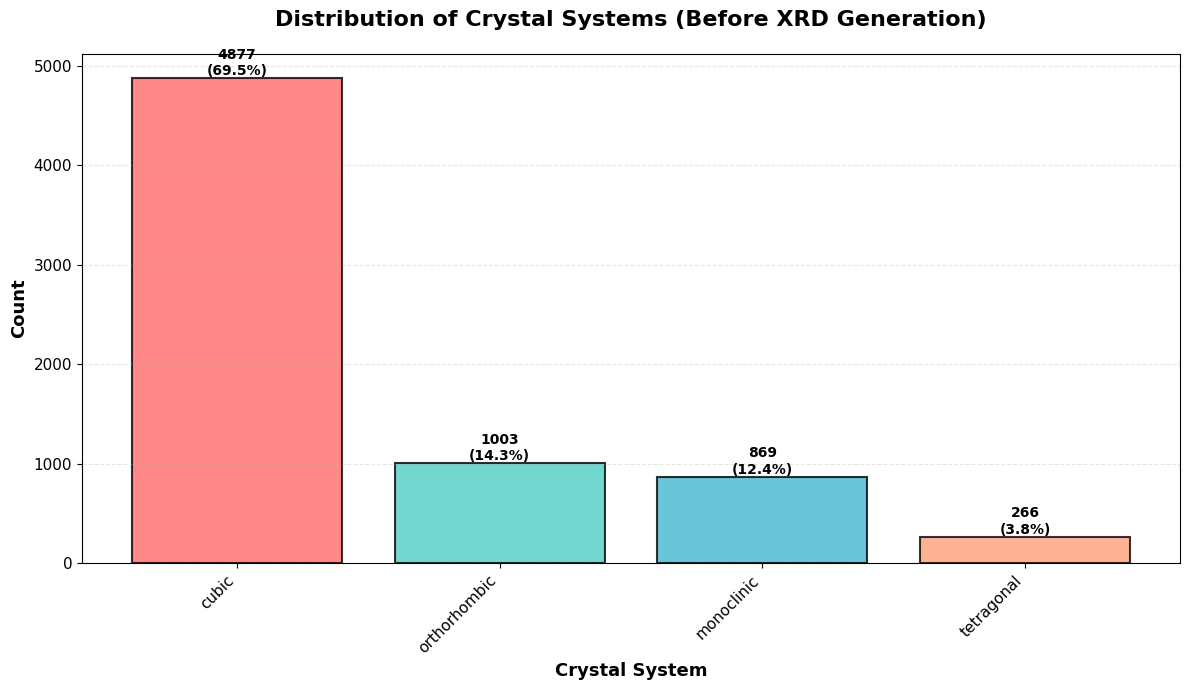

In [ ]:
# Distribution of crystal systems
print("\n" + "="*70)
print("CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)")
print("="*70)

class_distribution = df_materials['crystal_system'].value_counts()
print("\nCount by Crystal System:")
print(class_distribution)

print("\nPercentage by Crystal System:")
class_distribution_pct = (class_distribution / len(df_materials) * 100).round(2)
for system, pct in class_distribution_pct.items():
    print(f"  {system.capitalize():<15}: {pct:>6.2f}%")

# Plot distribution
plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(class_distribution.index, class_distribution.values,
               color=colors[:len(class_distribution)],
               edgecolor='black', linewidth=1.5, alpha=0.8)

plt.title('Distribution of Crystal Systems (Before XRD Generation)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Crystal System', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df_materials)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Generate XRD Patterns

In [ ]:
def generate_xrd_patterns(df_materials, two_theta_min=TWO_THETA_MIN,
                         two_theta_max=TWO_THETA_MAX, n_points=N_POINTS):
    """Generate XRD patterns from structures"""

    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns = []
    y_systems = []
    valid_indices = []
    failed_count = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS")
    print("="*70)
    print(f"2θ range: {two_theta_min}° - {two_theta_max}°")
    print(f"Number of points: {n_points}")
    print(f"Wavelength: Cu Kα")
    print()

    total = len(df_materials)

    for idx, row in df_materials.iterrows():
        try:
            structure = row['structure']
            pattern = xrd_calc.get_pattern(
                structure,
                two_theta_range=(two_theta_min, two_theta_max),
            )
            intensities = np.interp(two_theta_grid, pattern.x, pattern.y)

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:  # Only show first 3 errors
                print(f"✗ Error for {row['material_id']}: {str(e)[:50]}...")
            continue

        if (len(X_patterns) % 500) == 0:
            print(f"✓ Processed {len(X_patterns)}/{total} patterns... ({len(X_patterns)/total*100:.1f}%)")

    X_patterns = np.array(X_patterns, dtype=np.float32)
    y_systems = np.array(y_systems)

    print()
    print("="*70)
    print("XRD GENERATION SUMMARY")
    print("="*70)
    print(f"✓ Successfully generated: {len(X_patterns)} patterns")
    print(f"✗ Failed: {failed_count} patterns")
    print(f"Success rate: {len(X_patterns)/(len(X_patterns)+failed_count)*100:.2f}%")
    print(f"Pattern shape: {X_patterns.shape}")
    print(f"Crystal system distribution:\n{Counter(y_systems)}")

    return two_theta_grid, X_patterns, y_systems, valid_indices

# Generate XRD patterns
two_theta_grid, X_raw, y_str, valid_idx = generate_xrd_patterns(df_materials)

# Update dataframe to keep only valid materials
df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)

print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS
2θ range: 10° - 110°
Number of points: 2048
Wavelength: Cu Kα

✓ Processed 500/7015 patterns... (7.1%)
✓ Processed 1000/7015 patterns... (14.3%)
✓ Processed 1500/7015 patterns... (21.4%)
✓ Processed 2000/7015 patterns... (28.5%)
✓ Processed 2500/7015 patterns... (35.6%)
✓ Processed 3000/7015 patterns... (42.8%)
✓ Processed 3500/7015 patterns... (49.9%)
✓ Processed 4000/7015 patterns... (57.0%)
✓ Processed 4500/7015 patterns... (64.1%)
✓ Processed 5000/7015 patterns... (71.3%)
✓ Processed 5500/7015 patterns... (78.4%)
✓ Processed 6000/7015 patterns... (85.5%)
✓ Processed 6500/7015 patterns... (92.7%)
✓ Processed 7000/7015 patterns... (99.8%)

XRD GENERATION SUMMARY
✓ Successfully generated: 7015 patterns
✗ Failed: 0 patterns
Success rate: 100.00%
Pattern shape: (7015, 2048)
Crystal system distribution:
Counter({np.str_('cubic'): 4877, np.str_('orthorhombic'): 1003, np.str_('monoclinic'): 869, np.str_('tetragonal'): 266})

✓ Final dataset size: 7015 samples


Visualize XRD Patterns for Each Crystal System


XRD PATTERN VISUALIZATION
Displaying 1 sample per crystal system (sorted by 2θ)
Plotting Cubic: 4877 samples available
Plotting Monoclinic: 869 samples available
Plotting Orthorhombic: 1003 samples available
Plotting Tetragonal: 266 samples available


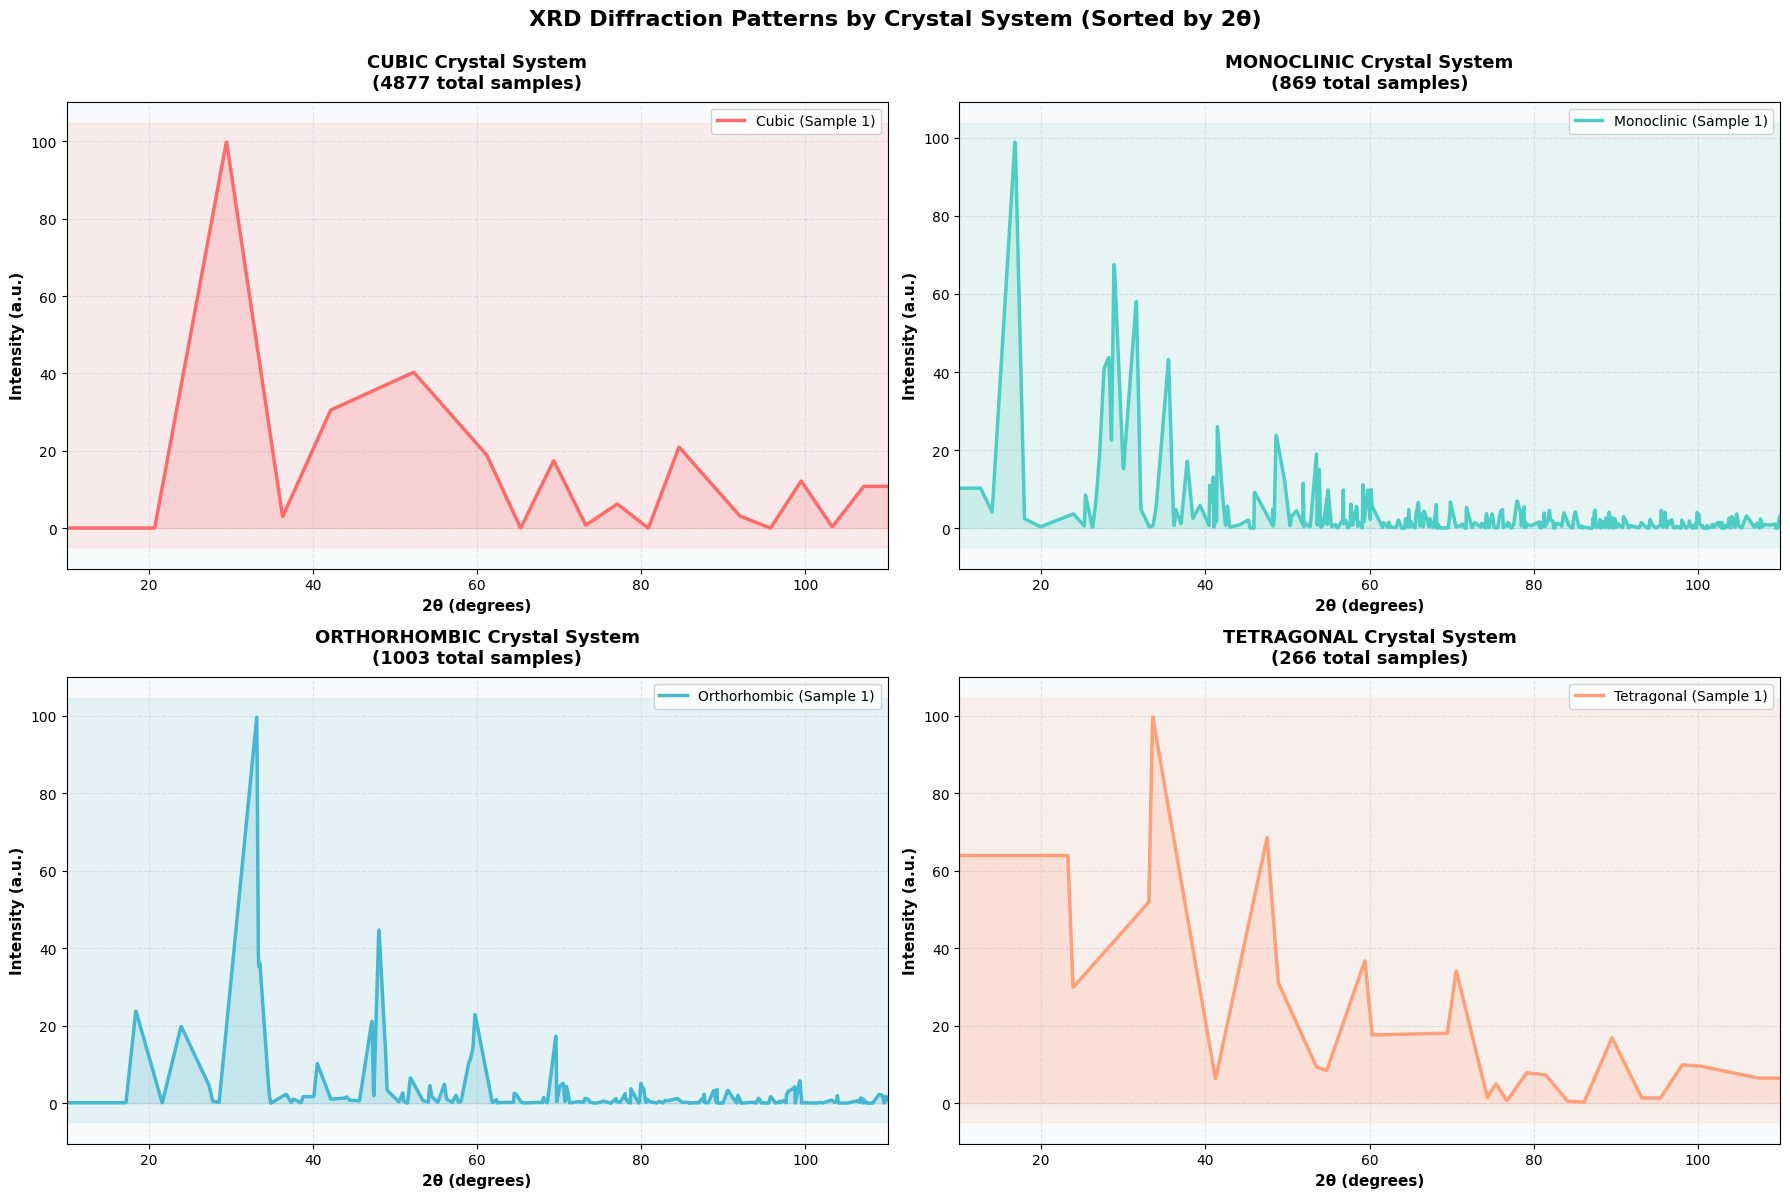


✓ XRD patterns visualization complete!
✓ Each pattern is sorted by 2θ angle


In [ ]:
# Plot example XRD patterns for each crystal system
print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION")
print("="*70)
print("Displaying 1 sample per crystal system (sorted by 2θ)")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

colors_map = {
    'cubic': '#FF6B6B',
    'monoclinic': '#4ECDC4',
    'orthorhombic': '#45B7D1',
    'tetragonal': '#FFA07A'
}

for idx, system in enumerate(TARGET_SYSTEMS):
    ax = axes[idx]

    # Get indices for this system
    system_indices = np.where(y_str == system)[0]

    print(f"Plotting {system.capitalize()}: {len(system_indices)} samples available")

    if len(system_indices) > 0:
        # Take only 1 sample (first sample)
        sample_idx = system_indices[0]

        # Get pattern data
        pattern_data = X_raw[sample_idx]

        # Sort by 2θ (should already be sorted, but ensuring)
        sorted_indices = np.argsort(two_theta_grid)
        two_theta_sorted = two_theta_grid[sorted_indices]
        pattern_sorted = pattern_data[sorted_indices]

        # Plot the sorted pattern
        ax.plot(two_theta_sorted, pattern_sorted,
               linewidth=2.5,
               color=colors_map[system],
               label=f'{system.capitalize()} (Sample 1)')

        # Fill under the curve for better visualization
        ax.fill_between(two_theta_sorted, pattern_sorted,
                        alpha=0.2, color=colors_map[system])

    ax.set_title(f'{system.upper()} Crystal System\n({len(system_indices)} total samples)',
                fontweight='bold', fontsize=13, pad=10)
    ax.set_xlabel('2θ (degrees)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_facecolor('#f8f9fa')

    # Add subtle background color
    ax.axhspan(ax.get_ylim()[0], ax.get_ylim()[1], alpha=0.1, color=colors_map[system])

    # Set x-axis limits
    ax.set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)

plt.suptitle('XRD Diffraction Patterns by Crystal System (Sorted by 2θ)',
            fontweight='bold', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ XRD patterns visualization complete!")
print("✓ Each pattern is sorted by 2θ angle")

Encode Labels & Split Data

In [ ]:
print("\n" + "="*70)
print("DATA PREPARATION: ENCODING & SPLITTING")
print("="*70)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_str)
class_names = list(le.classes_)

print("\nClass Encoding Mapping:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} → {name.capitalize():<15} ({count} samples)")

# Split data: 80% train, 20% test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

print("\n" + "-"*70)
print("DATA SPLIT (80% Train / 20% Test)")
print("-"*70)
print(f"Training set size:   {len(X_train_raw):>6} samples ({len(X_train_raw)/len(X_raw)*100:.1f}%)")
print(f"Test set size:       {len(X_test_raw):>6} samples ({len(X_test_raw)/len(X_raw)*100:.1f}%)")
print(f"Total:               {len(X_raw):>6} samples")

print("\nTraining Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_train)*100:>5.1f}%)")

print("\nTest Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_test)*100:>5.1f}%)")


DATA PREPARATION: ENCODING & SPLITTING

Class Encoding Mapping:
  0 → Cubic           (4877 samples)
  1 → Monoclinic      (869 samples)
  2 → Orthorhombic    (1003 samples)
  3 → Tetragonal      (266 samples)

----------------------------------------------------------------------
DATA SPLIT (80% Train / 20% Test)
----------------------------------------------------------------------
Training set size:     5612 samples (80.0%)
Test set size:         1403 samples (20.0%)
Total:                 7015 samples

Training Set Distribution:
  Cubic          :  3902 samples ( 69.5%)
  Monoclinic     :   695 samples ( 12.4%)
  Orthorhombic   :   802 samples ( 14.3%)
  Tetragonal     :   213 samples (  3.8%)

Test Set Distribution:
  Cubic          :   975 samples ( 69.5%)
  Monoclinic     :   174 samples ( 12.4%)
  Orthorhombic   :   201 samples ( 14.3%)
  Tetragonal     :    53 samples (  3.8%)


Apply SMOTE (Training Data Only)

In [ ]:
print("\n" + "="*70)
print("APPLYING SMOTE OVERSAMPLING (TRAINING DATA ONLY)")
print("="*70)

print("\nBEFORE SMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

# Apply SMOTE
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train)

print("\n" + "="*70)
print("AFTER SMOTE:")
print("-" * 50)
print(f"Training samples: {len(X_train_smote)} (increased by {len(X_train_smote) - len(X_train_raw)})")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train_smote == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n" + "="*70)
print("TEST SET (UNCHANGED - NO OVERSAMPLING):")
print("-" * 50)
print(f"Test samples: {len(X_test_raw)}")
print("\nClass distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples")

print("\n✓ SMOTE oversampling applied successfully!")
print(f"✓ Training data balanced: all classes now have {np.max(np.bincount(y_train_smote))} samples")


APPLYING SMOTE OVERSAMPLING (TRAINING DATA ONLY)

BEFORE SMOTE:
--------------------------------------------------
Training samples: 5612

Class distribution:
  Cubic          :  3902 samples
  Monoclinic     :   695 samples
  Orthorhombic   :   802 samples
  Tetragonal     :   213 samples

AFTER SMOTE:
--------------------------------------------------
Training samples: 15608 (increased by 9996)

Class distribution:
  Cubic          :  3902 samples
  Monoclinic     :  3902 samples
  Orthorhombic   :  3902 samples
  Tetragonal     :  3902 samples

TEST SET (UNCHANGED - NO OVERSAMPLING):
--------------------------------------------------
Test samples: 1403

Class distribution:
  Cubic          :   975 samples
  Monoclinic     :   174 samples
  Orthorhombic   :   201 samples
  Tetragonal     :    53 samples

✓ SMOTE oversampling applied successfully!
✓ Training data balanced: all classes now have 3902 samples


Visualize Distribution After SMOTE

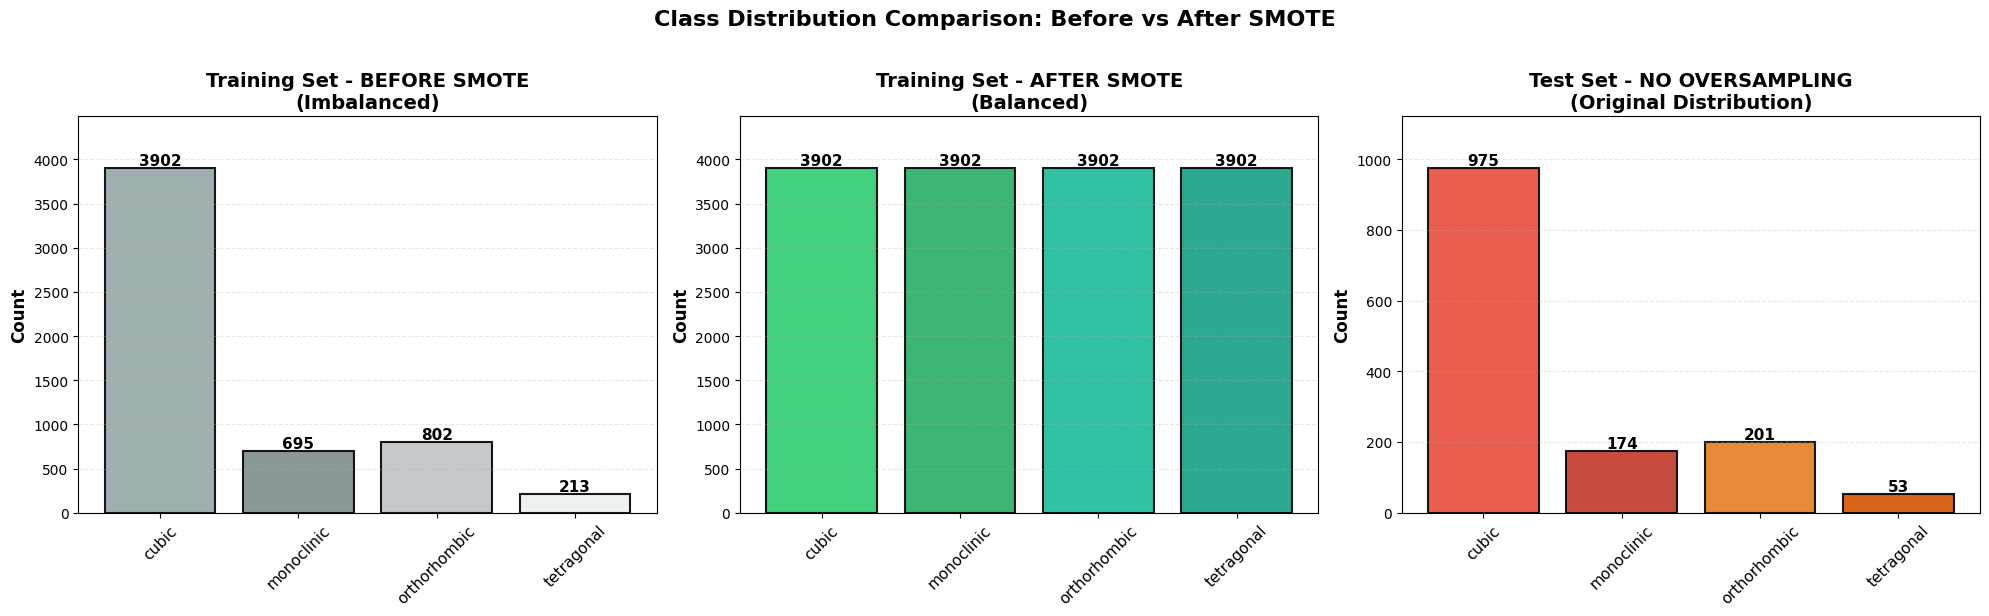

In [ ]:
# Visualize class distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Color palette
colors_before = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#ecf0f1']
colors_after = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
colors_test = ['#e74c3c', '#c0392b', '#e67e22', '#d35400']

# Plot 1: Before SMOTE
unique, counts = np.unique(y_train, return_counts=True)
labels = [class_names[i] for i in unique]
bars1 = axes[0].bar(labels, counts, color=colors_before, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[0].set_title('Training Set - BEFORE SMOTE\n(Imbalanced)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars1, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 2: After SMOTE
unique, counts = np.unique(y_train_smote, return_counts=True)
labels = [class_names[i] for i in unique]
bars2 = axes[1].bar(labels, counts, color=colors_after, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[1].set_title('Training Set - AFTER SMOTE\n(Balanced)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars2, counts):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Plot 3: Test Set
unique, counts = np.unique(y_test, return_counts=True)
labels = [class_names[i] for i in unique]
bars3 = axes[2].bar(labels, counts, color=colors_test, edgecolor='black', linewidth=1.5, alpha=0.9)
axes[2].set_title('Test Set - NO OVERSAMPLING\n(Original Distribution)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=11)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].set_ylim(0, max(counts) * 1.15)
for bar, count in zip(bars3, counts):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Class Distribution Comparison: Before vs After SMOTE',
            fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Display Sample Counts Summary

In [ ]:
# Summary table
print("\n" + "="*70)
print("SAMPLE COUNTS SUMMARY TABLE")
print("="*70)

summary_data = []
total_train_before = 0
total_train_after = 0
total_test = 0

for i, system in enumerate(class_names):
    train_before = np.sum(y_train == i)
    train_after = np.sum(y_train_smote == i)
    test_count = np.sum(y_test == i)

    total_train_before += train_before
    total_train_after += train_after
    total_test += test_count

    increase = train_after - train_before
    increase_pct = (increase / train_before * 100) if train_before > 0 else 0

    summary_data.append({
        'Crystal System': system.capitalize(),
        'Train (Before)': train_before,
        'Train (After)': train_after,
        'Increase': f'+{increase}',
        'Increase %': f'+{increase_pct:.1f}%',
        'Test (Unchanged)': test_count
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "-"*70)
print(f"{'TOTAL':<20} {total_train_before:>13} {total_train_after:>14} {f'+{total_train_after-total_train_before}':>10} {f'+{(total_train_after-total_train_before)/total_train_before*100:.1f}%':>12} {total_test:>17}")
print("="*70)

print("\n✓ SMOTE oversampling increased training samples by {:.1f}%".format(
    (total_train_after - total_train_before) / total_train_before * 100
))


SAMPLE COUNTS SUMMARY TABLE
Crystal System  Train (Before)  Train (After) Increase Increase %  Test (Unchanged)
         Cubic            3902           3902       +0      +0.0%               975
    Monoclinic             695           3902    +3207    +461.4%               174
  Orthorhombic             802           3902    +3100    +386.5%               201
    Tetragonal             213           3902    +3689   +1731.9%                53

----------------------------------------------------------------------
TOTAL                         5612          15608      +9996      +178.1%              1403

✓ SMOTE oversampling increased training samples by 178.1%


Build & Train CNN Model

In [ ]:
def build_cnn_1d_fixed(input_shape, num_classes: int):
    """
    Build CNN with fixed architecture
    - 3 Conv1D layers: filters=80, kernel_size=[100, 80, 20], stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout
    """
    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: 80 filters, kernel_size=100, stride=5
    x = layers.Conv1D(filters=80, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: 80 filters, kernel_size=80, stride=5
    x = layers.Conv1D(filters=80, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: 80 filters, kernel_size=20, stride=5
    x = layers.Conv1D(filters=80, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(64, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_Fixed")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

# Prepare data
X_train = X_train_smote[..., np.newaxis]
X_test = X_test_raw[..., np.newaxis]

# Build model
print("\n" + "="*70)
print("BUILDING CNN MODEL")
print("="*70)
print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1D: 80 filters, kernel=100, stride=5")
print("  - Conv2D: 80 filters, kernel=80,  stride=5")
print("  - Conv3D: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("-" * 70)

model_cnn = build_cnn_1d_fixed(X_train.shape[1:], num_classes=len(class_names))
model_cnn.summary()

# Train model
print("\n" + "="*70)
print("TRAINING CNN MODEL")
print("="*70)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_cnn = model_cnn.fit(
    X_train, y_train_smote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1,
    callbacks=[es]
)

print("\n✓ CNN Model training complete!")


BUILDING CNN MODEL

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1D: 80 filters, kernel=100, stride=5
  - Conv2D: 80 filters, kernel=80,  stride=5
  - Conv3D: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       512,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,364 (2.58 MB)

 Trainable params: 677,364 (2.58 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING CNN MODEL
Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6733 - loss: 0.8241 - val_accuracy: 0.2604 - val_loss: 1.5834
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8800 - loss: 0.3245 - val_accuracy: 0.5548 - val_loss: 1.1336
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9318 - loss: 0.2115 - val_accuracy: 0.8469 - val_loss: 0.4338
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9542 - loss: 0.1496 - val_accuracy: 0.7963 - val_loss: 0.5566
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9674 - loss: 0.1005 - val_accuracy: 0.8325 - val_loss: 0.5379
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.0804 - val_accuracy: 0.9254 - val_loss: 0.2239
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9757 - loss: 0.0839 - val_accuracy: 0.8953 - val_loss: 0.2896
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9810 - loss: 0.0

Evaluate CNN Model

In [ ]:
# Predict on test set
y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)

# Calculate metrics
acc_cnn = accuracy_score(y_test, y_pred_cnn)
prec_cnn = precision_score(y_test, y_pred_cnn, average="macro", zero_division=0)
rec_cnn = recall_score(y_test, y_pred_cnn, average="macro", zero_division=0)
f1_cnn = f1_score(y_test, y_pred_cnn, average="macro", zero_division=0)

print("\n" + "="*70)
print("CNN MODEL EVALUATION METRICS")
print("="*70)
print(f"Accuracy:  {acc_cnn:.4f}")
print(f"Precision: {prec_cnn:.4f}")
print(f"Recall:    {rec_cnn:.4f}")
print(f"F1-Score:  {f1_cnn:.4f}")

# Detailed classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_cnn, target_names=class_names))


CNN MODEL EVALUATION METRICS
Accuracy:  0.9309
Precision: 0.8297
Recall:    0.8124
F1-Score:  0.8195

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       cubic       0.99      0.98      0.99       975
  monoclinic       0.84      0.81      0.83       174
orthorhombic       0.80      0.87      0.83       201
  tetragonal       0.69      0.58      0.63        53

    accuracy                           0.93      1403
   macro avg       0.83      0.81      0.82      1403
weighted avg       0.93      0.93      0.93      1403



 Confusion Matrix for CNN

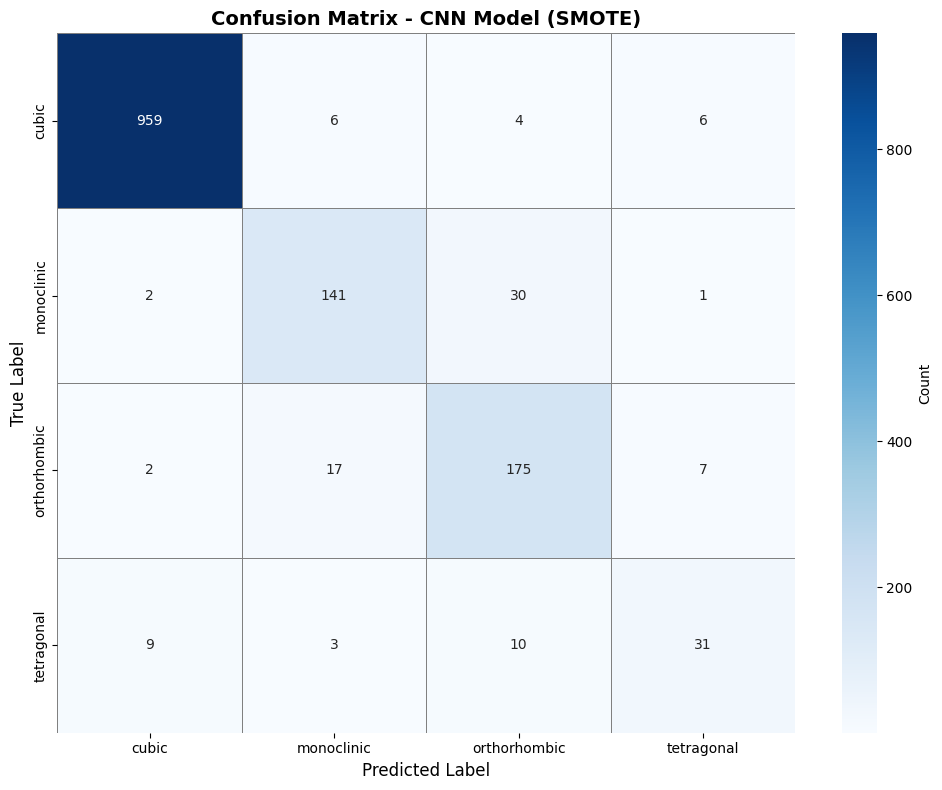


Per-Class Accuracy:
  cubic: 0.9836
  monoclinic: 0.8103
  orthorhombic: 0.8706
  tetragonal: 0.5849


In [ ]:
# Plot confusion matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray')

plt.title('Confusion Matrix - CNN Model (SMOTE)', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
for i, name in enumerate(class_names):
    class_acc = cm_cnn[i, i] / cm_cnn[i].sum() if cm_cnn[i].sum() > 0 else 0
    print(f"  {name}: {class_acc:.4f}")

t-SNE Visualization for CNN

t-SNE VISUALIZATION FOR CNN MODEL
Extracting CNN features for t-SNE visualization...
Applying t-SNE dimensionality reduction...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1403 samples in 0.000s...
[t-SNE] Computed neighbors for 1403 samples in 0.029s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1403
[t-SNE] Computed conditional probabilities for sample 1403 / 1403
[t-SNE] Mean sigma: 1.446316


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.337585
[t-SNE] KL divergence after 1000 iterations: 0.554065


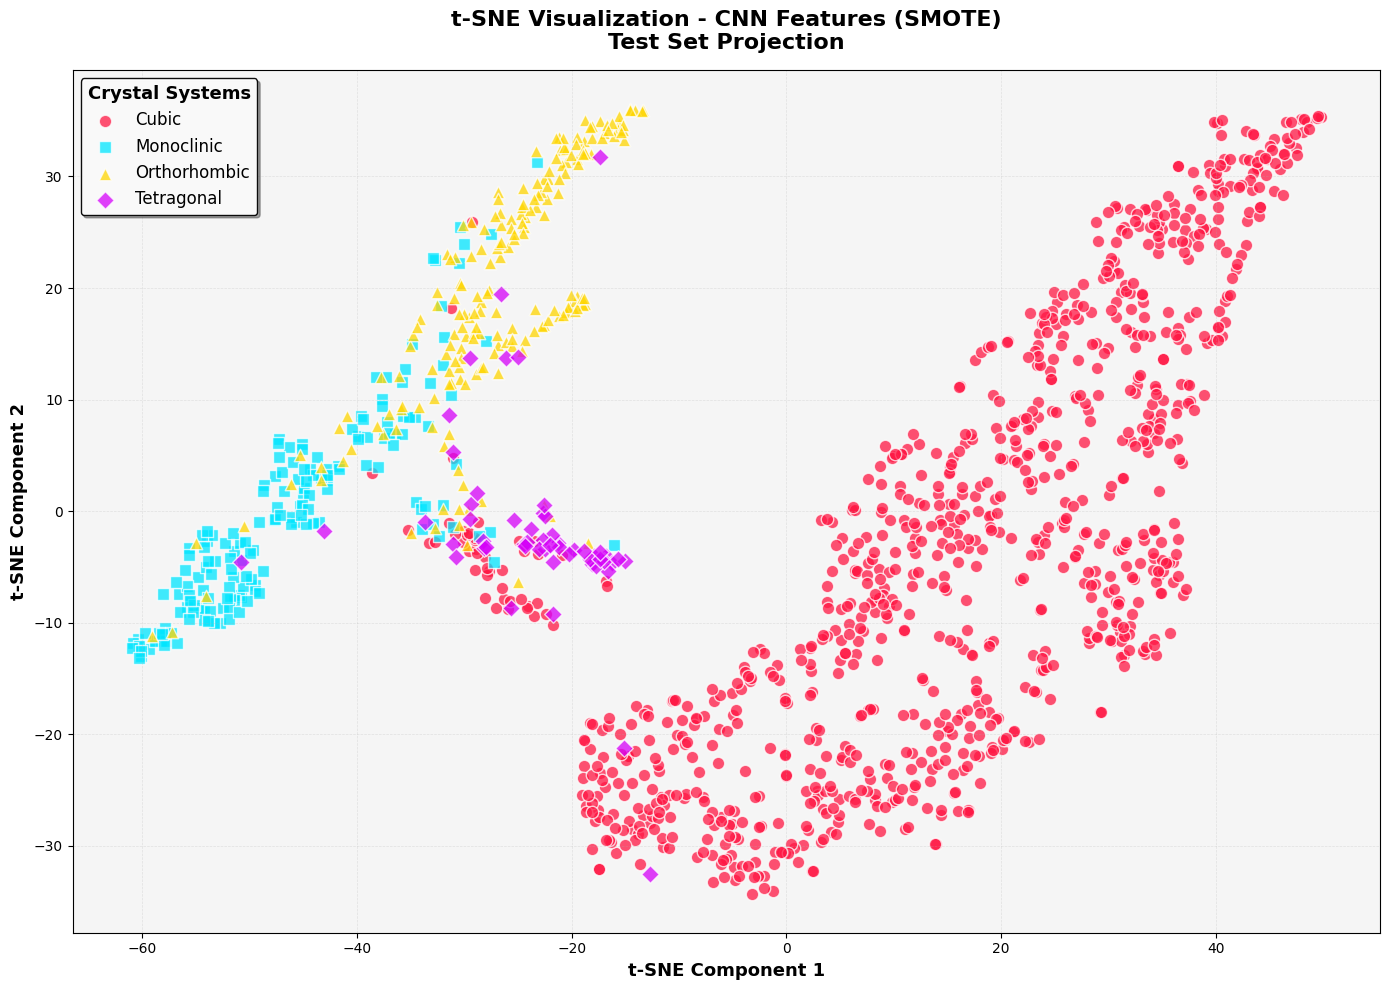


✓ t-SNE visualization complete!
✓ Visualized 1403 test samples


In [ ]:
# Extract features from CNN
def extract_cnn_features(model, X_data):
    """Extract features from feature layer"""
    if len(X_data.shape) == 2:
        X_data = X_data[..., np.newaxis]
    feature_layer = model.get_layer("feature_layer")
    feat_model = Model(inputs=model.input, outputs=feature_layer.output)
    return feat_model.predict(X_data, verbose=0, batch_size=32)

print("="*70)
print("t-SNE VISUALIZATION FOR CNN MODEL")
print("="*70)
print("Extracting CNN features for t-SNE visualization...")
X_test_features = extract_cnn_features(model_cnn, X_test_raw)

# Apply t-SNE
print("Applying t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000, verbose=1)
X_tsne_cnn = tsne.fit_transform(X_test_features)

# Plot t-SNE with bright, distinct colors
plt.figure(figsize=(14, 10))

# Bright and distinct color palette
colors_bright = [
    '#FF1744',  # Bright Red - Cubic
    '#00E5FF',  # Bright Cyan - Monoclinic
    '#FFD600',  # Bright Yellow - Orthorhombic
    '#D500F9'   # Bright Purple - Tetragonal
]

# Alternative bright color scheme
# colors_bright = [
#     '#FF3D00',  # Deep Orange
#     '#00BFA5',  # Teal
#     '#FFAB00',  # Amber
#     '#AA00FF'   # Purple
# ]

markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

for i, name in enumerate(class_names):
    mask = (y_test == i)
    plt.scatter(X_tsne_cnn[mask, 0], X_tsne_cnn[mask, 1],
               c=colors_bright[i],
               label=name.capitalize(),
               s=80,  # Larger point size
               alpha=0.75,
               edgecolors='white',  # White edge for better separation
               linewidths=1.0,
               marker=markers[i])  # Different marker shapes

plt.title('t-SNE Visualization - CNN Features (SMOTE)\nTest Set Projection',
         fontweight='bold', fontsize=16, pad=15)
plt.xlabel('t-SNE Component 1', fontsize=13, fontweight='bold')
plt.ylabel('t-SNE Component 2', fontsize=13, fontweight='bold')

# Enhanced legend
legend = plt.legend(fontsize=12, loc='best', framealpha=0.95,
                   edgecolor='black', fancybox=True, shadow=True)
legend.set_title('Crystal Systems', prop={'size': 13, 'weight': 'bold'})

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()

# Add background color
ax = plt.gca()
ax.set_facecolor('#F5F5F5')

plt.show()

print("\n✓ t-SNE visualization complete!")
print(f"✓ Visualized {len(X_test_features)} test samples")

CNN + WOA - Implementation

In [ ]:
# Whale Optimization Algorithm for CNN hyperparameter tuning
class WhaleOptimization:
    def __init__(self, n_whales, n_iterations, bounds):
        self.n_whales = n_whales
        self.n_iterations = n_iterations
        self.bounds = bounds
        self.dim = len(bounds)

    def initialize_population(self):
        """Initialize whale positions randomly within bounds"""
        population = np.zeros((self.n_whales, self.dim))
        for i in range(self.dim):
            population[:, i] = np.random.uniform(
                self.bounds[i][0],
                self.bounds[i][1],
                self.n_whales
            )
        return population

    def optimize(self, fitness_function):
        """Run WOA optimization"""
        # Initialize
        population = self.initialize_population()
        fitness = np.array([fitness_function(ind) for ind in population])

        # Best solution
        best_idx = np.argmax(fitness)
        best_position = population[best_idx].copy()
        best_fitness = fitness[best_idx]

        fitness_history = [best_fitness]

        print(f"Initial best fitness: {best_fitness:.4f}")

        # Optimization loop
        for iteration in range(self.n_iterations):
            a = 2 - iteration * (2 / self.n_iterations)  # Decreases from 2 to 0

            for i in range(self.n_whales):
                r1 = np.random.random()
                r2 = np.random.random()

                A = 2 * a * r1 - a
                C = 2 * r2

                p = np.random.random()

                if p < 0.5:
                    if abs(A) < 1:
                        # Encircling prey
                        D = abs(C * best_position - population[i])
                        population[i] = best_position - A * D
                    else:
                        # Search for prey (exploration)
                        rand_idx = np.random.randint(0, self.n_whales)
                        rand_whale = population[rand_idx]
                        D = abs(C * rand_whale - population[i])
                        population[i] = rand_whale - A * D
                else:
                    # Spiral updating position
                    D_prime = abs(best_position - population[i])
                    l = np.random.uniform(-1, 1)
                    population[i] = D_prime * np.exp(l) * np.cos(2 * np.pi * l) + best_position

                # Boundary check
                for j in range(self.dim):
                    population[i, j] = np.clip(
                        population[i, j],
                        self.bounds[j][0],
                        self.bounds[j][1]
                    )

            # Update fitness
            fitness = np.array([fitness_function(ind) for ind in population])

            # Update best
            current_best_idx = np.argmax(fitness)
            if fitness[current_best_idx] > best_fitness:
                best_fitness = fitness[current_best_idx]
                best_position = population[current_best_idx].copy()

            fitness_history.append(best_fitness)

            if (iteration + 1) % 2 == 0:
                print(f"Iteration {iteration + 1}/{self.n_iterations} - Best fitness: {best_fitness:.4f}")

        return best_position, best_fitness, fitness_history

print("✓ WOA class defined successfully!")

✓ WOA class defined successfully!


CNN + WOA - Training

In [ ]:
def build_cnn_woa(params, input_shape, num_classes):
    """
    Build CNN with WOA-optimized hyperparameters
    Architecture:
    - 3 Conv1D layers: all with kernel_size optimized, stride=5
    - Average Pooling after each conv layer
    - 2 Fully Connected layers with 30% Dropout

    WOA optimizes:
    - Number of filters for all 3 conv layers (same value)
    - Fully connected layer 1 units
    - Fully connected layer 2 units (feature layer)
    """
    num_filters = int(params[0])      # Filters for all 3 conv layers
    fc1_units = int(params[1])        # FC layer 1 units
    fc2_units = int(params[2])        # FC layer 2 units (feature layer)

    inputs = layers.Input(shape=input_shape)

    # Convolutional Layer 1: kernel_size=100, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=100, strides=5,
                      activation="relu", padding="same",
                      name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Convolutional Layer 2: kernel_size=80, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=80, strides=5,
                      activation="relu", padding="same",
                      name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Convolutional Layer 3: kernel_size=20, stride=5
    x = layers.Conv1D(filters=num_filters, kernel_size=20, strides=5,
                      activation="relu", padding="same",
                      name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Flatten
    x = layers.Flatten()(x)

    # Fully Connected Layer 1 with Dropout 30%
    x = layers.Dense(fc1_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)

    # Fully Connected Layer 2 (Feature Layer) with Dropout 30%
    x = layers.Dense(fc2_units, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = models.Model(inputs, outputs, name="CNN_WOA")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

def fitness_function(params):
    """Fitness function for WOA (validation accuracy)"""
    try:
        model = build_cnn_woa(params, X_train.shape[1:], len(class_names))

        history = model.fit(
            X_train, y_train_smote,
            epochs=5,  # Quick evaluation
            batch_size=BATCH_SIZE,
            validation_split=0.2,
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])

        tf.keras.backend.clear_session()

        return val_acc
    except Exception as e:
        print(f"Error in fitness function: {e}")
        return 0.0

# WOA hyperparameter bounds
# [num_filters, fc1_units, fc2_units]
bounds = [
    (64, 128),   # num_filters: 64-128 (for all 3 conv layers)
    (64, 256),   # fc1_units: 64-256
    (32, 128),   # fc2_units: 32-128 (feature layer)
]

print("\n" + "="*70)
print("OPTIMIZING CNN WITH WOA")
print("="*70)
print("WOA will optimize:")
print("  1. Number of filters (same for all 3 Conv layers)")
print("  2. Fully Connected Layer 1 units")
print("  3. Fully Connected Layer 2 units (feature layer)")
print()
print(f"Number of whales: 8")
print(f"Number of iterations: 10")
print(f"Hyperparameter bounds:")
print(f"  - Conv filters: {bounds[0]}")
print(f"  - FC1 units:    {bounds[1]}")
print(f"  - FC2 units:    {bounds[2]}")
print()

woa = WhaleOptimization(n_whales=8, n_iterations=10, bounds=bounds)
best_params, best_fitness, fitness_hist = woa.optimize(fitness_function)

print(f"\n{'='*70}")
print(f"WOA OPTIMIZATION COMPLETE!")
print(f"{'='*70}")
print(f"Best parameters: {best_params}")
print(f"  - Conv filters (all layers): {int(best_params[0])}")
print(f"  - FC1 units: {int(best_params[1])}")
print(f"  - FC2 units (feature layer): {int(best_params[2])}")
print(f"Best validation accuracy: {best_fitness:.4f}")


OPTIMIZING CNN WITH WOA
WOA will optimize:
  1. Number of filters (same for all 3 Conv layers)
  2. Fully Connected Layer 1 units
  3. Fully Connected Layer 2 units (feature layer)

Number of whales: 8
Number of iterations: 10
Hyperparameter bounds:
  - Conv filters: (64, 128)
  - FC1 units:    (64, 256)
  - FC2 units:    (32, 128)

Initial best fitness: 0.9202
Iteration 2/10 - Best fitness: 0.9202
Iteration 4/10 - Best fitness: 0.9324
Iteration 6/10 - Best fitness: 0.9324
Iteration 8/10 - Best fitness: 0.9324
Iteration 10/10 - Best fitness: 0.9324

WOA OPTIMIZATION COMPLETE!
Best parameters: [64. 64. 32.]
  - Conv filters (all layers): 64
  - FC1 units: 64
  - FC2 units (feature layer): 32
Best validation accuracy: 0.9324


Train Final CNN+WOA Model


TRAINING FINAL CNN+WOA MODEL


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 64)        │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 64)         │       327,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 64)          │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 426,660 (1.63 MB)

 Trainable params: 426,660 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6617 - loss: 0.8362 - val_accuracy: 0.1140 - val_loss: 1.6856
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8521 - loss: 0.4180 - val_accuracy: 0.5785 - val_loss: 1.1333
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9038 - loss: 0.2920 - val_accuracy: 0.8053 - val_loss: 0.7239
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9308 - loss: 0.2052 - val_accuracy: 0.7130 - val_loss: 0.7327
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9481 - loss: 0.1519 - val_accuracy: 0.8414 - val_loss: 0.4371
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9567 - loss: 0.1264 - val_accuracy: 0.8011 - val_loss: 0.6237
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9624 - loss: 0.1065 - val_accuracy: 0.9110 - val_loss: 0.2642
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9671 - loss: 0.1089 - val_accuracy: 

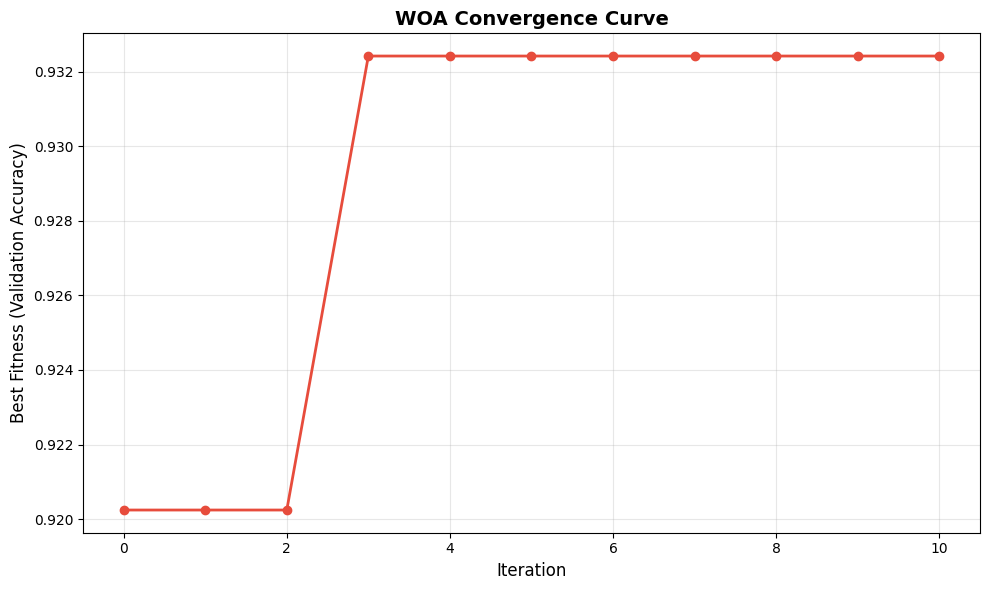

In [ ]:
# Train final model with best parameters
print("\n" + "="*70)
print("TRAINING FINAL CNN+WOA MODEL")
print("="*70)

model_cnn_woa = build_cnn_woa(best_params, X_train.shape[1:], len(class_names))
model_cnn_woa.summary()

es_woa = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_cnn_woa = model_cnn_woa.fit(
    X_train, y_train_smote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1,
    callbacks=[es_woa]
)

# Plot WOA convergence
plt.figure(figsize=(10, 6))
plt.plot(range(len(fitness_hist)), fitness_hist,
         marker='o', linewidth=2, markersize=6, color='#e74c3c')
plt.title('WOA Convergence Curve', fontweight='bold', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Fitness (Validation Accuracy)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evaluate CNN+WOA Model

In [ ]:
# Predict on test set
y_pred_cnn_woa = np.argmax(model_cnn_woa.predict(X_test, verbose=0), axis=1)

# Calculate metrics
acc_cnn_woa = accuracy_score(y_test, y_pred_cnn_woa)
prec_cnn_woa = precision_score(y_test, y_pred_cnn_woa, average="macro", zero_division=0)
rec_cnn_woa = recall_score(y_test, y_pred_cnn_woa, average="macro", zero_division=0)
f1_cnn_woa = f1_score(y_test, y_pred_cnn_woa, average="macro", zero_division=0)

print("\n" + "="*70)
print("CNN+WOA MODEL EVALUATION METRICS")
print("="*70)
print(f"Accuracy:  {acc_cnn_woa:.4f}")
print(f"Precision: {prec_cnn_woa:.4f}")
print(f"Recall:    {rec_cnn_woa:.4f}")
print(f"F1-Score:  {f1_cnn_woa:.4f}")

# Detailed classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, y_pred_cnn_woa, target_names=class_names))


CNN+WOA MODEL EVALUATION METRICS
Accuracy:  0.9259
Precision: 0.7962
Recall:    0.8218
F1-Score:  0.8074

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       cubic       0.99      0.98      0.98       975
  monoclinic       0.84      0.80      0.82       174
orthorhombic       0.82      0.87      0.84       201
  tetragonal       0.53      0.64      0.58        53

    accuracy                           0.93      1403
   macro avg       0.80      0.82      0.81      1403
weighted avg       0.93      0.93      0.93      1403



Confusion Matrix for CNN+WOA

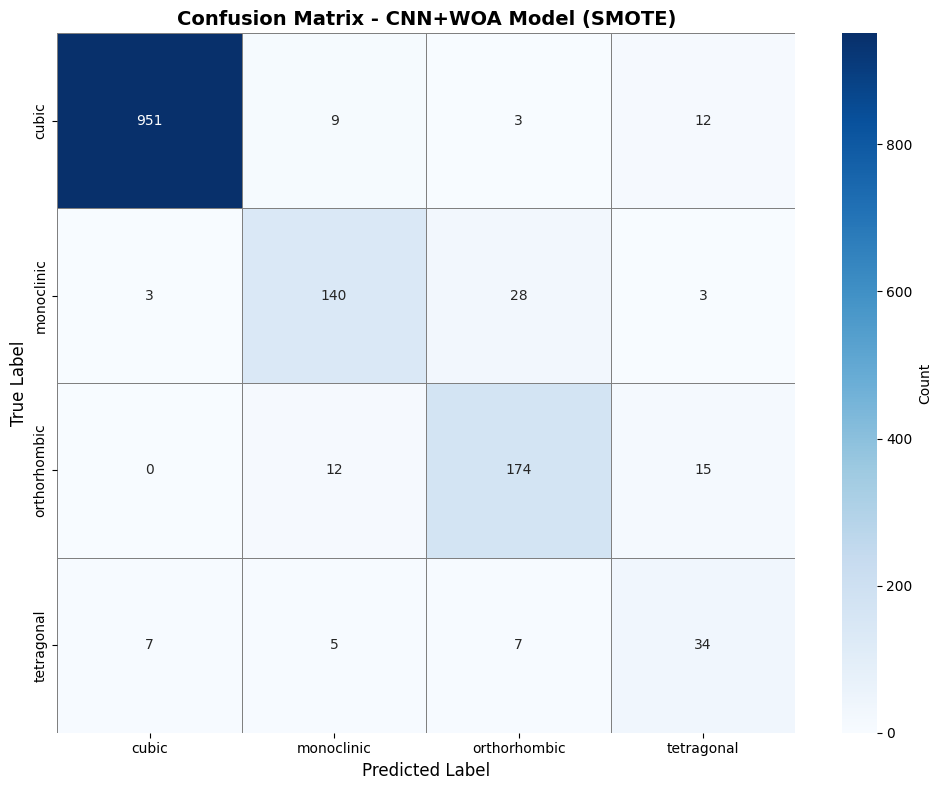


Per-Class Accuracy:
  cubic: 0.9754
  monoclinic: 0.8046
  orthorhombic: 0.8657
  tetragonal: 0.6415


In [ ]:
# Plot confusion matrix
cm_cnn_woa = confusion_matrix(y_test, y_pred_cnn_woa)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn_woa, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray')

plt.title('Confusion Matrix - CNN+WOA Model (SMOTE)', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
for i, name in enumerate(class_names):
    class_acc = cm_cnn_woa[i, i] / cm_cnn_woa[i].sum() if cm_cnn_woa[i].sum() > 0 else 0
    print(f"  {name}: {class_acc:.4f}")

 t-SNE Visualization for CNN+WOA

Extracting CNN+WOA features for t-SNE visualization...
Applying t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


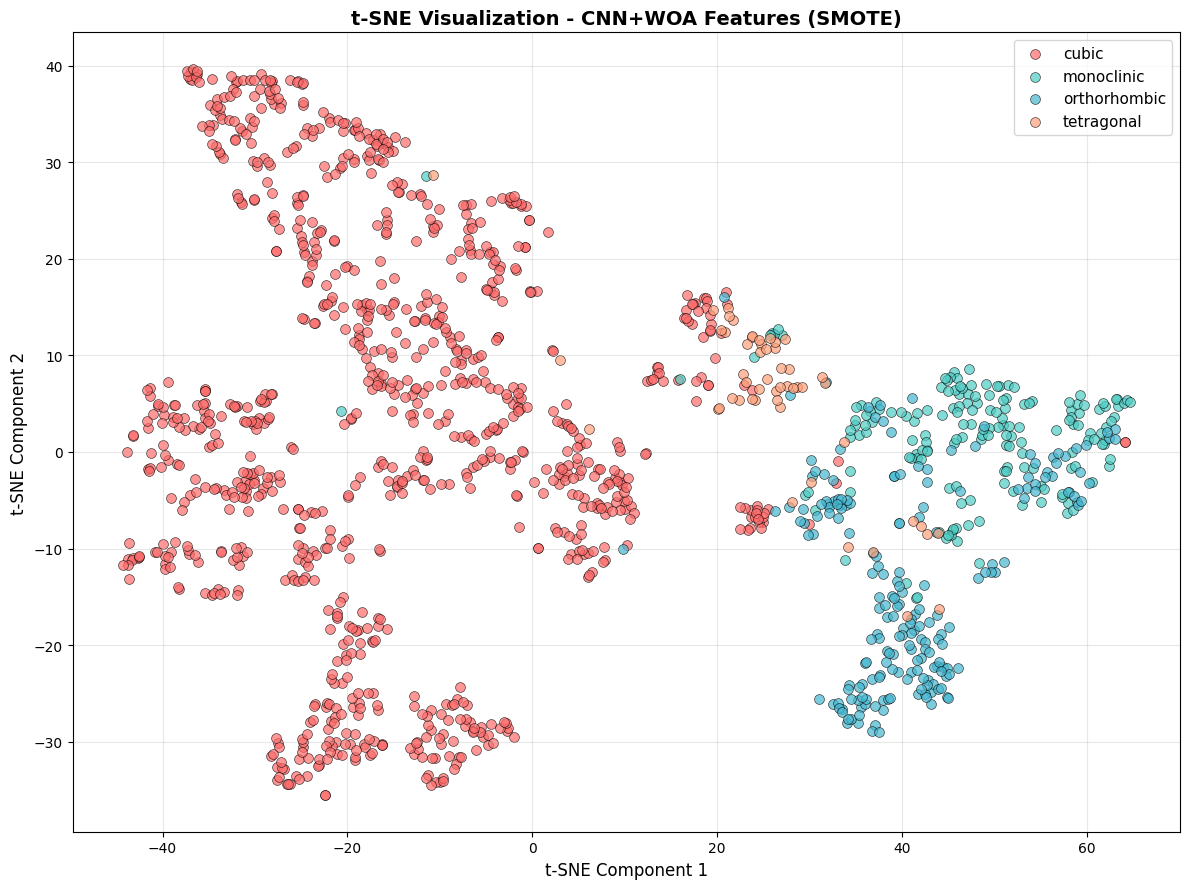

In [ ]:
# Extract features from CNN+WOA
print("Extracting CNN+WOA features for t-SNE visualization...")
X_test_features_woa = extract_cnn_features(model_cnn_woa, X_test_raw)

# Apply t-SNE
print("Applying t-SNE...")
tsne_woa = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
X_tsne_cnn_woa = tsne_woa.fit_transform(X_test_features_woa)

# Plot t-SNE
plt.figure(figsize=(12, 9))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for i, name in enumerate(class_names):
    mask = (y_test == i)
    plt.scatter(X_tsne_cnn_woa[mask, 0], X_tsne_cnn_woa[mask, 1],
               c=colors[i], label=name, s=50, alpha=0.7,
               edgecolors='black', linewidths=0.5)

plt.title('t-SNE Visualization - CNN+WOA Features (SMOTE)',
         fontweight='bold', fontsize=14)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

t-SNE VISUALIZATION FOR CNN+WOA MODEL
Extracting CNN+WOA features for t-SNE visualization...
Applying t-SNE dimensionality reduction...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1403 samples in 0.000s...
[t-SNE] Computed neighbors for 1403 samples in 0.032s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1403
[t-SNE] Computed conditional probabilities for sample 1403 / 1403
[t-SNE] Mean sigma: 0.538240


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.605156
[t-SNE] KL divergence after 1000 iterations: 0.604945


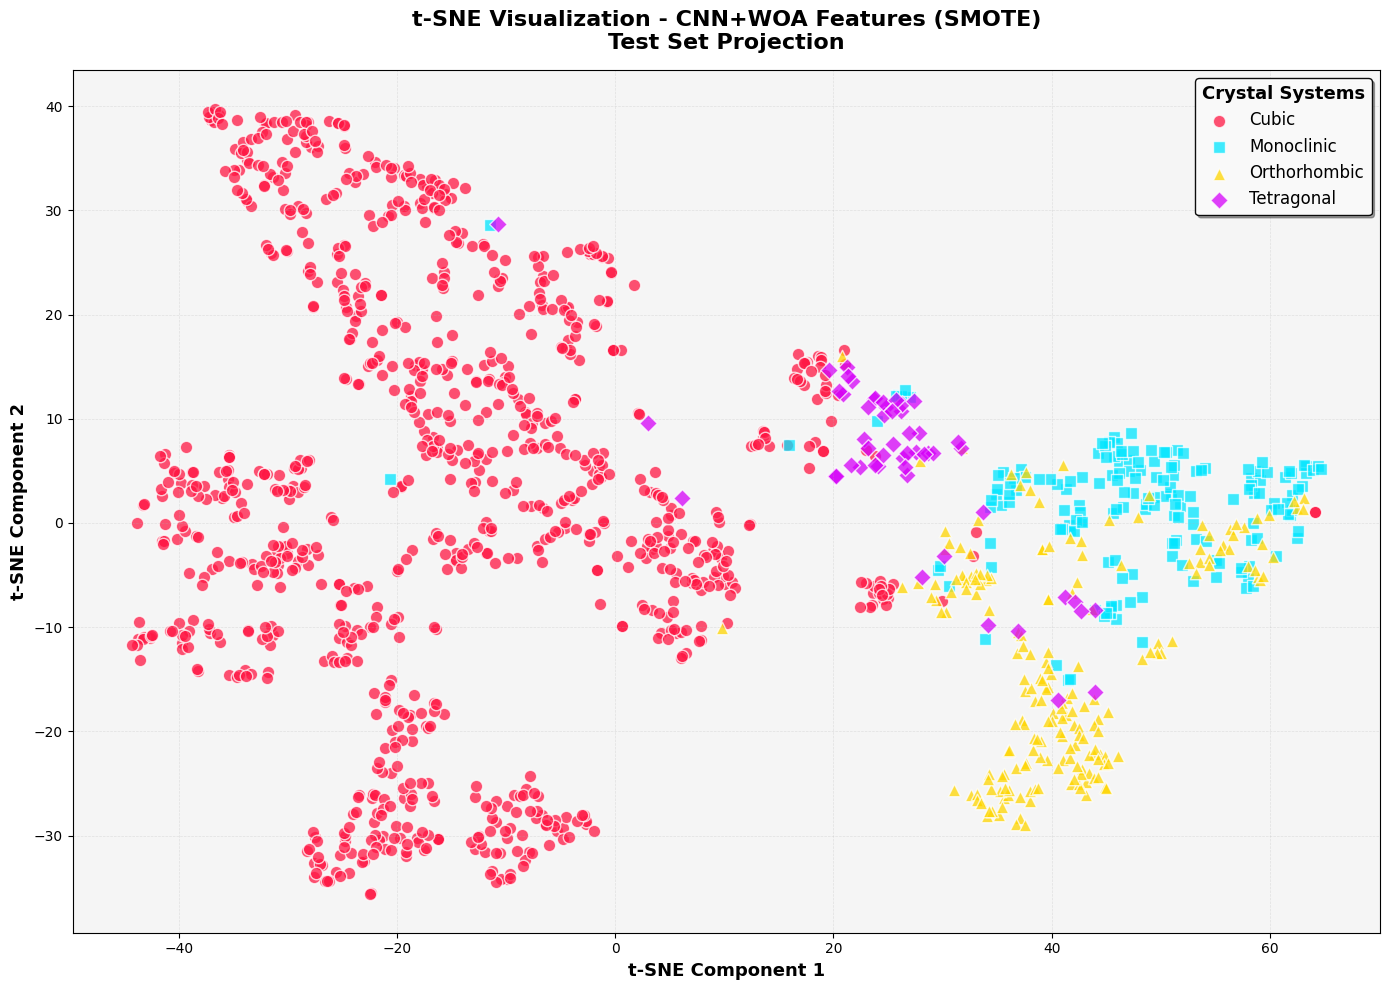


✓ t-SNE visualization complete!
✓ Visualized 1403 test samples


In [ ]:
# Extract features from CNN+WOA
print("="*70)
print("t-SNE VISUALIZATION FOR CNN+WOA MODEL")
print("="*70)
print("Extracting CNN+WOA features for t-SNE visualization...")
X_test_features_woa = extract_cnn_features(model_cnn_woa, X_test_raw)

# Apply t-SNE
print("Applying t-SNE dimensionality reduction...")
tsne_woa = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000, verbose=1)
X_tsne_cnn_woa = tsne_woa.fit_transform(X_test_features_woa)

# Plot t-SNE with bright, distinct colors
plt.figure(figsize=(14, 10))

# Bright and distinct color palette (same as CNN for consistency)
colors_bright = [
    '#FF1744',  # Bright Red - Cubic
    '#00E5FF',  # Bright Cyan - Monoclinic
    '#FFD600',  # Bright Yellow - Orthorhombic
    '#D500F9'   # Bright Purple - Tetragonal
]

markers = ['o', 's', '^', 'D']  # circle, square, triangle, diamond

for i, name in enumerate(class_names):
    mask = (y_test == i)
    plt.scatter(X_tsne_cnn_woa[mask, 0], X_tsne_cnn_woa[mask, 1],
               c=colors_bright[i],
               label=name.capitalize(),
               s=80,  # Larger point size
               alpha=0.75,
               edgecolors='white',  # White edge for better separation
               linewidths=1.0,
               marker=markers[i])  # Different marker shapes

plt.title('t-SNE Visualization - CNN+WOA Features (SMOTE)\nTest Set Projection',
         fontweight='bold', fontsize=16, pad=15)
plt.xlabel('t-SNE Component 1', fontsize=13, fontweight='bold')
plt.ylabel('t-SNE Component 2', fontsize=13, fontweight='bold')

# Enhanced legend
legend = plt.legend(fontsize=12, loc='best', framealpha=0.95,
                   edgecolor='black', fancybox=True, shadow=True)
legend.set_title('Crystal Systems', prop={'size': 13, 'weight': 'bold'})

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.tight_layout()

# Add background color
ax = plt.gca()
ax.set_facecolor('#F5F5F5')

plt.show()

print("\n✓ t-SNE visualization complete!")
print(f"✓ Visualized {len(X_test_features_woa)} test samples")

Comparison t-sne di feature layer vs output layer in CNN 1D

COMPARISON: Feature Layer vs Output Layer for t-SNE
Feature Layer shape: (1403, 64)
Output Layer shape: (1403, 4)

Contoh untuk sampel pertama:
Feature Layer (64 dimensi): [2.3585482  0.         0.         1.2349591  0.         0.
 1.7375327  0.         0.         0.26074725]... (showing first 10)
Output Layer (4 dimensi): [9.9234527e-01 3.3865813e-03 9.0081448e-04 3.3673677e-03]
Predicted class: cubic

Applying t-SNE on Feature Layer (64D)...
Applying t-SNE on Output Layer (4D)...


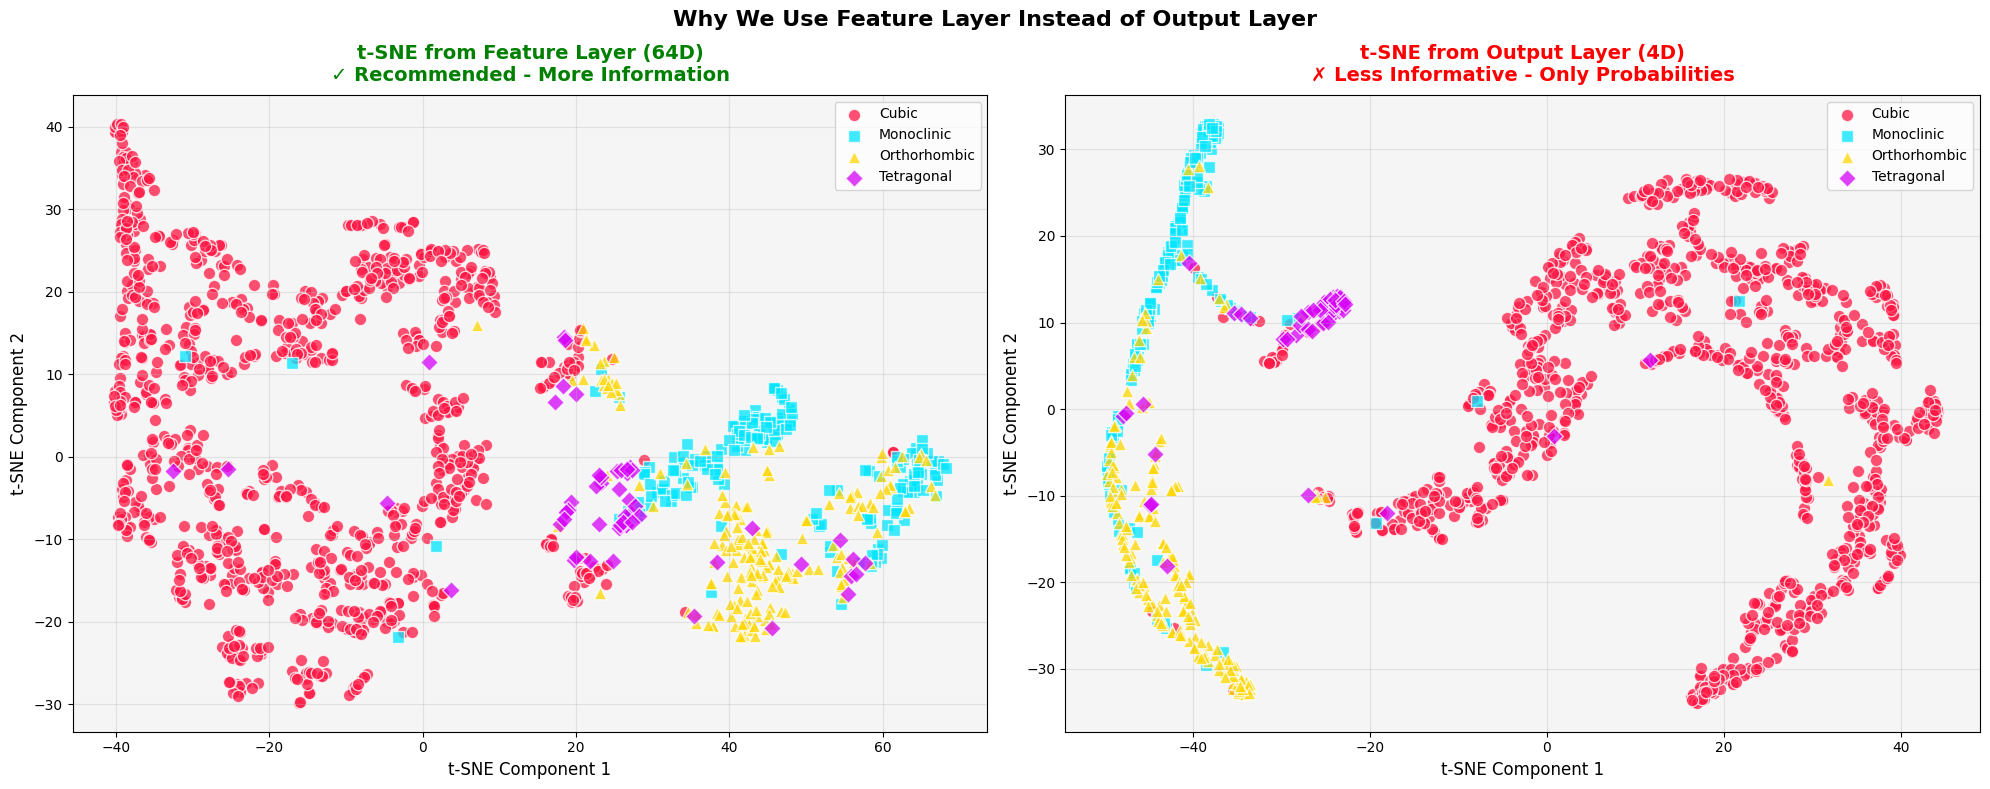


CONCLUSION:
✓ Feature Layer (64D): Richer representation, better separation
✗ Output Layer (4D): Only final probabilities, less informative

Feature Layer shows HOW the model understands the data
Output Layer only shows WHAT the model decides


In [ ]:
print("="*70)
print("COMPARISON: Feature Layer vs Output Layer for t-SNE")
print("="*70)

# Extract dari Feature Layer (Dense 64)
X_features_layer = extract_cnn_features(model_cnn, X_test_raw)
print(f"Feature Layer shape: {X_features_layer.shape}")  # (n_samples, 64)

# Extract dari Output Layer (Softmax 4)
X_output_layer = model_cnn.predict(X_test, verbose=0)
print(f"Output Layer shape: {X_output_layer.shape}")    # (n_samples, 4)

# Contoh untuk 1 sampel
print("\nContoh untuk sampel pertama:")
print(f"Feature Layer (64 dimensi): {X_features_layer[0][:10]}... (showing first 10)")
print(f"Output Layer (4 dimensi): {X_output_layer[0]}")
print(f"Predicted class: {class_names[np.argmax(X_output_layer[0])]}")

# t-SNE dari Feature Layer (64D)
print("\nApplying t-SNE on Feature Layer (64D)...")
tsne_features = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne_features = tsne_features.fit_transform(X_features_layer)

# t-SNE dari Output Layer (4D)
print("Applying t-SNE on Output Layer (4D)...")
tsne_output = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne_output = tsne_output.fit_transform(X_output_layer)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

colors_bright = ['#FF1744', '#00E5FF', '#FFD600', '#D500F9']
markers = ['o', 's', '^', 'D']

# Plot 1: t-SNE dari Feature Layer (64D)
ax1 = axes[0]
for i, name in enumerate(class_names):
    mask = (y_test == i)
    ax1.scatter(X_tsne_features[mask, 0], X_tsne_features[mask, 1],
               c=colors_bright[i], label=name.capitalize(),
               s=80, alpha=0.75, edgecolors='white', linewidths=1.0, marker=markers[i])
ax1.set_title('t-SNE from Feature Layer (64D)\n✓ Recommended - More Information',
             fontweight='bold', fontsize=14, pad=10, color='green')
ax1.set_xlabel('t-SNE Component 1', fontsize=12)
ax1.set_ylabel('t-SNE Component 2', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#F5F5F5')
ax1.legend(fontsize=10)

# Plot 2: t-SNE dari Output Layer (4D)
ax2 = axes[1]
for i, name in enumerate(class_names):
    mask = (y_test == i)
    ax2.scatter(X_tsne_output[mask, 0], X_tsne_output[mask, 1],
               c=colors_bright[i], label=name.capitalize(),
               s=80, alpha=0.75, edgecolors='white', linewidths=1.0, marker=markers[i])
ax2.set_title('t-SNE from Output Layer (4D)\n✗ Less Informative - Only Probabilities',
             fontweight='bold', fontsize=14, pad=10, color='red')
ax2.set_xlabel('t-SNE Component 1', fontsize=12)
ax2.set_ylabel('t-SNE Component 2', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#F5F5F5')
ax2.legend(fontsize=10)

plt.suptitle('Why We Use Feature Layer Instead of Output Layer',
            fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CONCLUSION:")
print("="*70)
print("✓ Feature Layer (64D): Richer representation, better separation")
print("✗ Output Layer (4D): Only final probabilities, less informative")
print("\nFeature Layer shows HOW the model understands the data")
print("Output Layer only shows WHAT the model decides")
print("="*70)